The code below implements channel/pipe flow using a solution to the NS equations that simulate flow through a pipe. In this case, the flow moves only to the right, but mroe quickly at the center of the mesh than at the top and bottom, where walls and viscosity would slow and stop the flow.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from petsc4py import PETSc
# Add current directory to path just in case
sys.path.append(os.path.abspath('../src'))

from tutorial_module import NavierStokesSolver

solver = NavierStokesSolver(
    n_cells=32,
    exact_u=lambda t, x, y: 4.0 * y * (1.0 - y), # Parabola: 0 at walls, max at y=0.5
    exact_v=lambda t, x, y: 0.0,                 # No vertical movement
    exact_p=lambda t, x, y: 1.0 - x              # High pressure on left, low on right
)

# (Run your plotting code here to see the beautiful parabolic arrows!)
solver.create_mesh()
solver.setup_discretization()

# This runs the TS solver and returns the PETSc Vec containing the solution
solution = solver.solve()
print(f"Solver finished at time: {solver.ts.getTime()}")

L2 Error Norm: 0.00e+00
Solver finished at time: 0.05


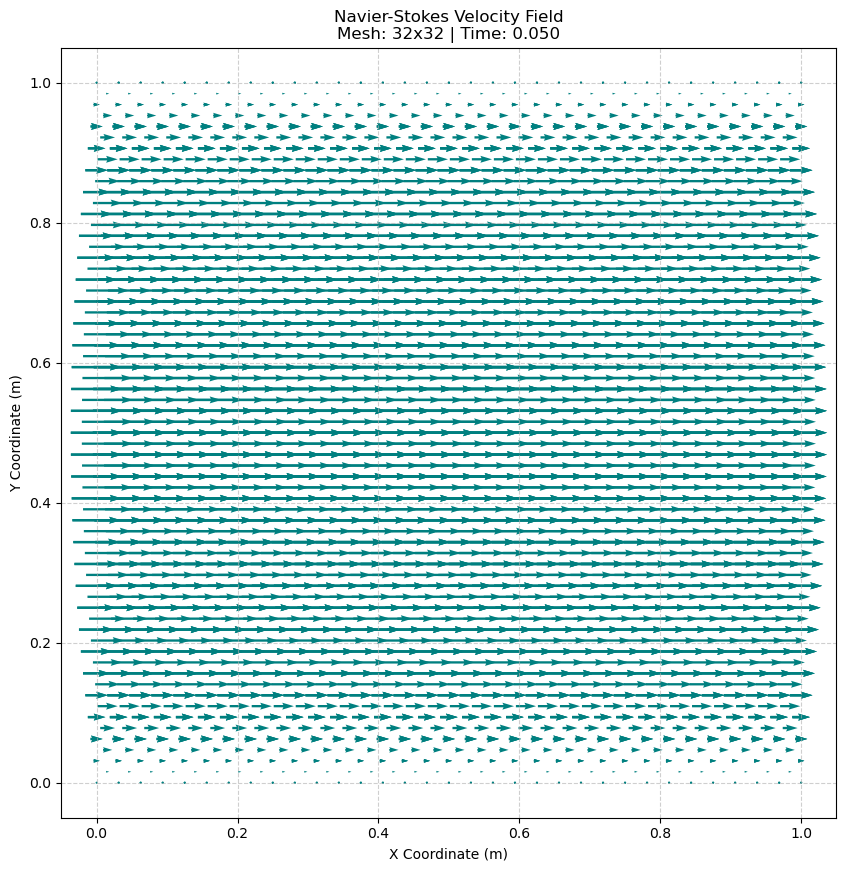

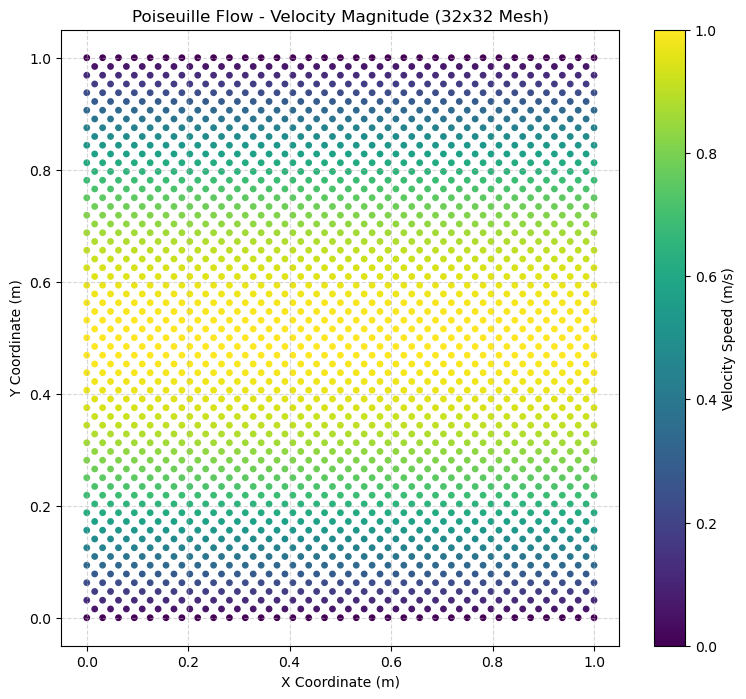

In [2]:
# 1. Access the raw data arrays
u_array = solution.getArray(readonly=True)
sol_section = solver.dm.getGlobalSection()

# 2. Access the coordinate mapping objects
coord_sec = solver.dm.getCoordinateSection()
coords_vec = solver.dm.getCoordinatesLocal()
coords_arr = coords_vec.getArray(readonly=True)

# Storage for plotting
x_vals, y_vals, u_vel, v_vel = [], [], [], []

# 3. Iterate over the entire mesh chart (vertices + edges + faces)
pStart, pEnd = solver.dm.getChart()

for pt in range(pStart, pEnd):
    # Determine if this point carries Velocity in the solution vector
    dof = sol_section.getDof(pt)
    off = sol_section.getOffset(pt)
    
    # If off >= 0, the point exists on this processor rank
    # If dof >= 2, the point carries at least u and v velocity components
    if off >= 0 and dof >= 2:
        # Use our helper function to find the REAL (x,y) location
        # This handles vertices AND the midpoints of edges (Q2 nodes)
        x, y = solver._get_true_coords(pt, coord_sec, coords_arr)
        
        # Append coordinates
        x_vals.append(x)
        y_vals.append(y)
        
        # Extract u and v from the solution vector
        # Taylor-Hood ordering at a point is [u, v, p] or [u, v]
        u_vel.append(u_array[off])
        v_vel.append(u_array[off+1])

# 4. Generate the Plot
plt.figure(figsize=(10, 10))

# Quiver plot configuration:
# pivot='mid' places the center of the arrow on the coordinate
# scale=15 adjusts arrow length; decrease for larger arrows
Q = plt.quiver(x_vals, y_vals, u_vel, v_vel, 
               color='teal', 
               pivot='mid', 
               scale=15, 
               width=0.003)

# Add a grid and set limits to show the full 1.0 x 1.0 domain
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title(f"Navier-Stokes Velocity Field\nMesh: {solver.n}x{solver.n} | Time: {solver.ts.getTime():.3f}")

plt.savefig("example_4x4.png")
plt.show()

# Extract the data
x_vals, y_vals, u_vel, v_vel = solver.extract_velocity_field(solution)

# Calculate the speed (magnitude) of the velocity at each point
speed = np.sqrt(np.array(u_vel)**2 + np.array(v_vel)**2)

# Plot a beautiful heatmap instead of chaotic arrows
plt.figure(figsize=(9, 8))
# Use a scatter plot with colors representing speed
scatter = plt.scatter(x_vals, y_vals, c=speed, cmap='viridis', s=15)
plt.colorbar(scatter, label='Velocity Speed (m/s)')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.title("Poiseuille Flow - Velocity Magnitude (32x32 Mesh)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()